# Expected Loss Credit Risk Model

This project develops a forward-looking credit risk modeling framework using the LendingClub consumer loan dataset. The objective is to estimate portfolio credit risk through the Expected Loss formula:

Expected Loss = Probability of Default (PD) × Loss Given Default (LGD) × Exposure at Default (EAD)

The modeling pipeline includes:
* A logistic regression model to estimate borrower probability of default  
* A two-stage model to estimate loss given default  
* A portfolio-level Expected Loss framework combining PD, LGD, and EAD  

Key Results:
* Portfolio Expected Loss: $4.32B  
* Average Expected Loss per Loan: $1,911  
* Portfolio Expected Loss Rate: 12.7%  
* PD Model ROC-AUC: ~0.72 with strong calibration

Risk segmentation analysis shows that expected losses increase monotonically from Grade A to Grade G borrowers, while small business loans exhibit the highest average expected loss among loan purposes.

This project demonstrates how machine learning techniques can be integrated with financial risk modeling to evaluate portfolio credit risk.

# Section 1 -  Data Loading and Initial Cleaning

We load the LendingClub dataset and select features relevant for credit risk modeling. We remove identifiers and post-default variables to avoid data leakage.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/archive (1)/loan.csv", low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (2260668, 145)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


We keep only origination-time variables to ensure forward-looking modeling. Variables observed after loan performance (e.g., recoveries, total payments) are excluded to prevent data leakage.

In [2]:
pd_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "addr_state"
]

df_clean = df[pd_features + ["loan_status"]].copy()


# Section 2 -  Target Engineering

To build a historical PD model, we restrict the dataset to resolved loans (Fully Paid, Charged Off, Default). We define binary default_flag indicating eventual default.

In [3]:
df_resolved = df_clean[df_clean["loan_status"].isin(
    ["Fully Paid", "Charged Off", "Default"]
)].copy()

df_resolved["default_flag"] = (
    df_resolved["loan_status"].isin(["Charged Off", "Default"])
).astype(int)

print(df_resolved["default_flag"].value_counts())
print("Default rate:", df_resolved["default_flag"].mean())

default_flag
0    1041952
1     261686
Name: count, dtype: int64
Default rate: 0.20073517341470562


To model active portfolio risk, we define a broader bad_flag including delinquent and defaulted loans. We define distressed statuses and construct a forward-looking bad_flag. We retain only loans that are clearly classified as good or bad. This definition allows the PD model to score active (“Current”) loans, making it suitable for portfolio-level Expected Loss estimation.

In [4]:
bad_statuses = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)",
    "In Grace Period",
    "Does not meet the credit policy. Status:Charged Off"
]

good_statuses = [
    "Fully Paid",
    "Current",
    "Does not meet the credit policy. Status:Fully Paid"
]

df_portfolio = df_clean[df_clean["loan_status"].isin(bad_statuses + good_statuses)].copy()

df_portfolio["bad_flag"] = df_portfolio["loan_status"].isin(bad_statuses).astype(int)

print(df_portfolio["bad_flag"].value_counts())
print("Bad rate:", df_portfolio["bad_flag"].mean())

bad_flag
0    1963635
1     297033
Name: count, dtype: int64
Bad rate: 0.1313916948441788


# Section 3 - Probability of Default (PD) Modeling

We develop two PD models:
1. A historical model predicting eventual default among resolved loans
2. A forward-looking model predicting distress in the active portfolio.

Logistic regression is used with consistent preprocessing to ensure interpretability and stability.

3.1.1 Historical PD Model (Resolved Loans)

We split resolved loans into train.test sets using stratification so the default rate is similar in both sets.

In [5]:
from sklearn.model_selection import train_test_split

X_hist = df_resolved[pd_features]
y_hist = df_resolved["default_flag"]

X_train_hist, X_test_hist, y_train_hist, y_test_hist = train_test_split(
    X_hist, y_hist, test_size=0.2, random_state=42, stratify=y_hist
)

print("Train shape:", X_train_hist.shape, "Test shape:", X_test_hist.shape)
print("Train default rate:", y_train_hist.mean(), "Test default rate:", y_test_hist.mean())

Train shape: (1042910, 20) Test shape: (260728, 20)
Train default rate: 0.20073544217621847 Test default rate: 0.20073409837071585


3.1.2 Preprocessing

We preprocess numeric and categorical features using:
- Median imputation + standard scaling for numeric variables
- Most frequent inputation + one-hot encoding for categorical variables

This preprocessing is fit on the training set within the pipeline to avoid leakage.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc"
]

categorical_features = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state"
]

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer( 
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)



Numeric: 12
Categorical: 8


3.1.3 Model Training

We train a logistic regression model with the same preprocessing pipeline used throughout this project.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

PD_hist_CLF = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

PD_hist_CLF.fit(X_train_hist, y_train_hist)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

3.1.4 Evaluation

We evaluate ranking performance using ROC AUC and PR AUC, and check calibration by comparing average predicted PD to the observed default rate.


In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score

p_hist = PD_hist_CLF.predict_proba(X_test_hist)[:, 1]

roc_hist = roc_auc_score(y_test_hist, p_hist)
pr_hist = average_precision_score(y_test_hist, p_hist)

print(f"Historical PD ROC AUC: {roc_hist:.4f}")
print(f"Historical PD PR AUC:  {pr_hist:.4f}")
print("Avg predicted PD:", p_hist.mean())

Historical PD ROC AUC: 0.7094
Historical PD PR AUC:  0.3724
Avg predicted PD: 0.2008697029312554


3.2.1 Forward-Looking PD Model (Portfolio Risk)

We now train a forward-looking PD model using bad_flag, which includes delinquency and default. This lets the model score active loans (Current) and is the PD used later for portfolio Expected Loss.

In [9]:
X_port = df_portfolio[pd_features]
y_port = df_portfolio["bad_flag"]

X_train_port, X_test_port, y_train_port, y_test_port = train_test_split(
    X_port, y_port, test_size=0.2, random_state=42, stratify=y_port
)

print("Train shape:", X_train_port.shape, "Test shape:", X_test_port.shape)
print("Train bad rate:", y_train_port.mean(), "Test bad rate:", y_test_port.mean())

Train shape: (1808534, 20) Test shape: (452134, 20)
Train bad rate: 0.1313915027309412 Test bad rate: 0.13139246329627943


3.2.2 Model Training

We fit the same logistic regression pipeline, now l earning a forward-looking definition of risk. 

In [10]:
PD_port_CLF = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

PD_port_CLF.fit(X_train_port, y_train_port)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

3.2.3 Evaluation

We evaluate the forward-looking model using ROC AUC and PR AUC, and verify calibration by comparing average predicted PD to the observed bad rate.

Now, we are going to find our target variable, "loan_status", and interpret it. 

In [11]:
p_port = PD_port_CLF.predict_proba(X_test_port)[:, 1]

roc_port = roc_auc_score(y_test_port, p_port)
pr_port = average_precision_score(y_test_port, p_port)

print(f"Forward-Looking PD ROC AUC: {roc_port:.4f}")
print(f"Forward-Looking PD PR AUC:  {pr_port:.4f}")
print("Avg predicted PD:", p_port.mean())

Forward-Looking PD ROC AUC: 0.7157
Forward-Looking PD PR AUC:  0.2728
Avg predicted PD: 0.13154144605863177


For the Expected Loss section, we use the forward-looking PD model (PD_port_CLF) because it reflects active portfolio risk and includes Current loans.

# Section 4 - Loss Given Default (LGD) Modeling

4.1 Build LGD Dataset 

We restric the dataset to defaulted loans and compute LGD using recoveries relative to funded amount. LGD is clipped between 0 and 1 to handle edge cases.

In [12]:
df_lgd = df[df["loan_status"].isin(["Charged Off", "Default"])].copy()

df_lgd["recovery_rate"] = df_lgd["recoveries"] / df_lgd["funded_amnt"]

df_lgd["lgd"] = 1 - df_lgd["recovery_rate"]

df_lgd["lgd"] = df_lgd["lgd"].clip(0, 1)

print("Shape:", df_lgd.shape)
print("Average LGD:", df_lgd["lgd"].mean())
print("Percent with LGD = 1:", (df_lgd["lgd"] == 1).mean() * 100)

Shape: (261686, 147)
Average LGD: 0.9267398440234411
Percent with LGD = 1: 32.456073309233204


4.2 LGD Distribution

We visualize LGD to confirm the typical unsecured lending pattern (large spike near 1).

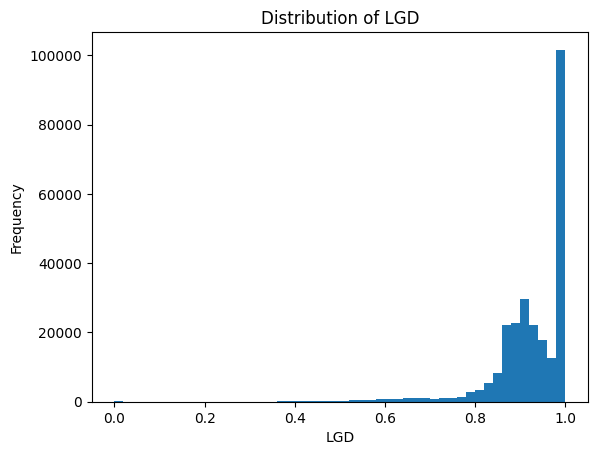

In [13]:
import matplotlib.pyplot as plt

plt.hist(df_lgd["lgd"], bins=50)
plt.title("Distribution of LGD")
plt.xlabel("LGD")
plt.ylabel("Frequency")
plt.show()

### 4.3 Stage 1 - Full Loss Classification

Stage 1 predicts whether a default results in a full loss (LGD = 1).

In [14]:
from sklearn.base import clone
df_lgd["full_loss_flag"] = (df_lgd["lgd"] == 1).astype(int)

X_stage1 = df_lgd[pd_features]
y_stage1 = df_lgd["full_loss_flag"]

X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X_stage1, y_stage1, test_size=0.2, random_state=42, stratify=y_stage1
)

lgd_stage1_clf = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000))
])

lgd_stage1_clf.fit(X_train_stage1, y_train_stage1)

p_stage1 = lgd_stage1_clf.predict_proba(X_test_stage1)[:, 1]

print("Stage 1 (Full Loss) ROC AUC:", roc_auc_score(y_test_stage1, p_stage1))
print("Stage 1 (Full Loss) PR AUC:", average_precision_score(y_test_stage1, p_stage1))

Stage 1 (Full Loss) ROC AUC: 0.6036597844832353
Stage 1 (Full Loss) PR AUC: 0.41657096033674956


### 4.4 Stage 2 - Partial Loss Severity Regression

Stage 2 models LGD severity for partial-loss loans only (LGD < 1).

In [15]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

df_partial = df_lgd[df_lgd["lgd"] < 1].copy()

X_stage2 = df_partial[pd_features]
y_stage2 = df_partial["lgd"]

X_train_stage2, X_test_stage2, y_train_stage2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42
)

lgd_stage2_reg = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", Ridge(alpha=1.0))
])

lgd_stage2_reg.fit(X_train_stage2, y_train_stage2)

y_pred_stage2 = lgd_stage2_reg.predict(X_test_stage2)

print("Stage 2 (Partial LGD) RMSE:",
      np.sqrt(mean_squared_error(y_test_stage2, y_pred_stage2)))
print("Stage 2 (Partial LGD) MAE:",
      mean_absolute_error(y_test_stage2, y_pred_stage2))
print("Stage 2 (Partial LGD) R^2:",
      r2_score(y_test_stage2, y_pred_stage2))

Stage 2 (Partial LGD) RMSE: 0.09534146985176138
Stage 2 (Partial LGD) MAE: 0.05714202040858739
Stage 2 (Partial LGD) R^2: 0.016213776305439076


### 4.5 Combine Stage 1 and Stage 2

We combine both stages to compute expected LGD: 

E|LGD| = P(full loss) * 1 + (1 - P(full loss)) * LGD_partial

In [16]:
p_full = lgd_stage1_clf.predict_proba(X_test_stage1)[:, 1]

lgd_partial_hat = lgd_stage2_reg.predict(X_test_stage1)

lgd_combined = p_full * 1 + (1 - p_full) * lgd_partial_hat

y_test_lgd = df_lgd.loc[X_test_stage1.index, "lgd"]

print("Combined LGD RMSE:", np.sqrt(mean_squared_error(y_test_lgd, lgd_combined)))
print("Combined LGD MAE:", mean_absolute_error(y_test_lgd, lgd_combined))
print("Combined LGD R^2:", r2_score(y_test_lgd, lgd_combined))

Combined LGD RMSE: 0.09295827609451014
Combined LGD MAE: 0.06267258544978781
Combined LGD R^2: 0.02004232020092589


# Section 5 - Expected Loss (PD x LGD x EAD)

5.1 Expected Loss Framework

Expected Loss (EL) is defined as:
- EL = PD x LGD x EAD

Where: 
- PD = Probability of Default (forward-looking model)
- LGD = Expected Loss Given Default (two-stage model)
- EAD = Exposure at Default (loan amount)

We compute Expected Loss at the loan level and then aggregate to the portfolio level.

5.2 Compute Forward-Looking PD

We use the forward-looking PD model to score the active portfolio.

In [17]:
pd_probs = PD_port_CLF.predict_proba(df_portfolio[pd_features])[:, 1]

print("Average PD:", pd_probs.mean())

Average PD: 0.13140132622601788


5.3 Compute Expected LGD for the Same Loans

We apply the two-LGD framework to estimate expected LGD for each loan.

In [18]:
p_full_all = lgd_stage1_clf.predict_proba(df_portfolio[pd_features])[:, 1]

lgd_partial_all = lgd_stage2_reg.predict(df_portfolio[pd_features])

expected_lgd = p_full_all * 1 + (1 - p_full_all) * lgd_partial_all

print("Average Expected LGD:", expected_lgd.mean())

Average Expected LGD: 0.9329572725501158


5.4 Define Exposure at Default (EAD)

We use loan amount as proxy for EAD.

In [19]:
ead = df_portfolio["loan_amnt"].values

print("Total Exposure:", ead.sum())

Total Exposure: 34016115925


5.5 Compute Loan-Level Expected Loss

We compute Expected Loss for each loan.

In [20]:
expected_loss = pd_probs * expected_lgd * ead

print("Total Portfolio Expected Loss:", expected_loss.sum())
print("Average EL per loan:", expected_loss.mean())
print("Portfolio EL Rate:", expected_loss.sum() / ead.sum())

Total Portfolio Expected Loss: 4320124215.431841
Average EL per loan: 1910.9945447238786
Portfolio EL Rate: 0.12700227812478684


### 5.6 Portfolio Interpretation

The forward-looking Expected Loss model estimates a total portfolio expected loss of approximately **$4.32 billion**, corresponding to an average expected loss of **$1,911 per loan**. Relative to total exposure, this implies a **portfolio expected loss rate of 12.7%**. 

This resul reflects the combined effect of:
- A forward-looking probability of distress (PD),
- A high average expected LGD consistent with usecured consumer lending,
- And the underlying exposure distribution across loans.

The portfolio EL rate of 12.7% indicates that, on average, the model expects to lose approximately 13 cents per dollar of exposure under current credit conditions. This estimate is economically plausible given the distressed loan share and high LGD observed in the dataset. The framework successfully integrates PD, LGD, and EAD into a coherent forward-looking credit risk estimate suitable for portfolio-level analysis.

# Section 6 - Risk Segmentation Analysis

## 6.1 Create Portfolio Results Table

To analyse portfolio risk, we combine model outputs into a single table containing:

* Probability of Default (PD)
* Expected Loss Given Default (LGD)
* Exposure at Default (EAD)
* Expecetd Loss (EL)

This table will allow us to analyze risk across borrower segments such as loan grade and loan purpose.

In [21]:
df_results = df_portfolio.copy()

df_results["PD"] = pd_probs
df_results["expected_LGD"] = expected_lgd
df_results["EAD"] = ead

df_results["EL"] = (
    df_results["PD"]
    * df_results["expected_LGD"]
    * df_results["EAD"]
)

df_results[["grade", "purpose", "PD", "expected_LGD", "EAD", "EL"]].head()

,grade,purpose,PD,expected_LGD,EAD,EL
0,C,debt_consolidation,0.111970,0.929846,2500,260.286995
1,D,debt_consolidation,0.170642,0.919314,30000,4706.204876
2,D,debt_consolidation,0.105866,0.930915,5000,492.763498
3,D,debt_consolidation,0.092456,0.936230,4000,346.241804
4,C,debt_consolidation,0.099137,0.935750,30000,2783.022514


## Expected Loss By Loan Grade

Loan grades summarize borrower credit quality. Lower grades typically correspond to higher risk borrowers.

We analyze how Expected Loss varies across loan grades in order to undrestand how credit risk is distributed across the portfolio.

In [22]:
el_by_grade = (
    df_results
    .groupby("grade")["EL"]
    .mean()
    .sort_index()
)

print(el_by_grade)

grade
A     505.444858
B    1166.907461
C    2047.254729
D    3074.422720
E    4667.103170
F    6543.895910
G    7571.226150
Name: EL, dtype: float64


## 6.3 Visualizing Expected Loss by Grade

We visualize the average Expected Loss across loan grades. This helps illustrates how credit quality impacts expected losses.

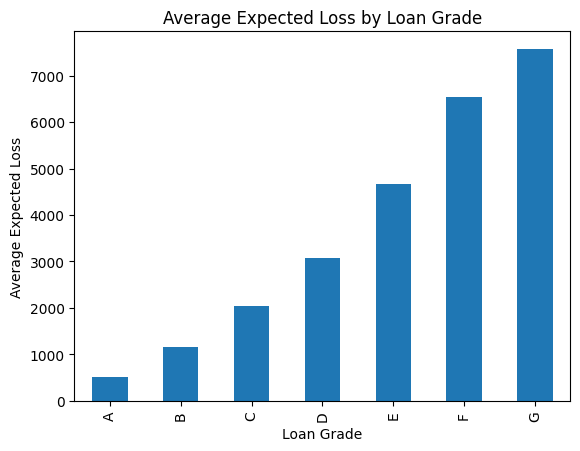

In [23]:
import matplotlib.pyplot as plt

el_by_grade.plot(kind="bar")

plt.title("Average Expected Loss by Loan Grade")
plt.ylabel("Average Expected Loss")
plt.xlabel("Loan Grade")

plt.show()

## 6.4 Expected Loss by Loan Purpose

Different loan purposes may exhibit different credit risk profiles.

We analyze expected loss across loan purposes to identify which borrowing categories contribute most to portfolio risk.

In [24]:
el_by_purpose = (
    df_results
    .groupby("purpose")["EL"]
    .mean()
    .sort_values(ascending=False)
)

print(el_by_purpose.head(10))

purpose
small_business        3159.727229
debt_consolidation    2179.388631
house                 1881.221666
renewable_energy      1704.661144
home_improvement      1682.798338
credit_card           1576.597876
wedding               1555.628513
major_purchase        1546.761240
other                 1350.393596
medical               1296.183462
Name: EL, dtype: float64


## 6.5 Interpretation

The risk segmentation analysis provides insight into how expected losses are distributed across different borrower groups within the portfolio.

Across loan grades, the results show a clear and economically intuitive pattern. Average expected loss increases steadily as borrower credit quality declines. For example, loans in **Grade A** exhibit an average expected loss of approximately **$505**, while **Grade G** loans have an average expected loss of roughly **$7,571**. This represents more than a **15-fold increase in expected loss between the safest and riskiest borrower categories**. The monotonic increase across grades confirms that the model is capturing the underlying credit risk structure of the LendingClub grading system.

The visualization of expected loss by grade further highlights this relationship. Expected losses rise consistently from **Grade A through Grade G**, reflecting the combined impact of higher probabilities of default and similar loss severities across lower credit quality borrowers. This pattern is consistent with financial intuition and supports the validity of the Expected Loss framework.

Loan purpose also reveals meaningful variation in portfolio risk. Loans issued for **small business purposes** exhibit the highest average expected loss at approximately **$3,160**, suggesting these borrowers may face greater financial volatility or repayment uncertainty. In contrast, purposes such as **medical, other, and major purchases** show lower expected losses, generally around **$1,300–$1,550** per loan.

Debt consolidation loans, which represent a large portion of the LendingClub portfolio, show an intermediate risk level with an average expected loss of approximately **$2,179**. This suggests that while these loans are common, they still carry moderate credit risk compared with other borrowing categories.

Overall, the segmentation analysis demonstrates that the Expected Loss framework successfully identifies how credit risk varies across borrower characteristics. Both **credit grade and loan purpose** provide meaningful signals about portfolio risk distribution, allowing analysts to identify higher-risk borrower segments and better understand the drivers of expected losses across the portfolio.


# Section 7 - Model Diagnostics

## 7.1 PD Distribution

We examine the distribution of predicted probabilities of default (PD) across the portfolio. This helps verify that the model produces a realistic range of probabilities rather than concentrating predictions around a single value.

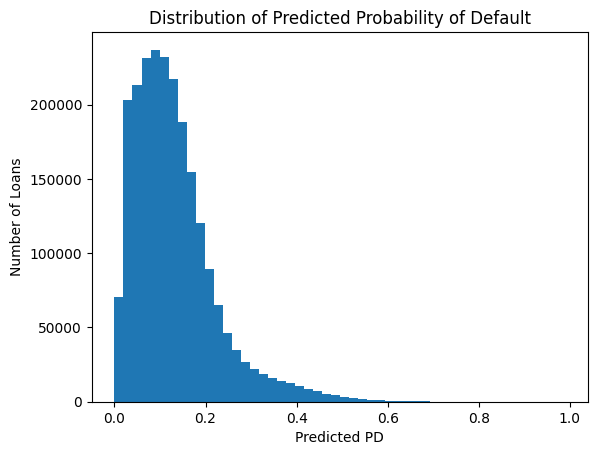

In [25]:
import matplotlib.pyplot as plt

plt.hist(pd_probs, bins=50)

plt.title("Distribution of Predicted Probability of Default")
plt.xlabel("Predicted PD")
plt.ylabel("Number of Loans")

plt.show()

## 7.2 ROC Curve

The ROC curve evaluates the model's ability to distinguish between good and bad loans. A model with a strong discriminatory power will produce a curve that rises sharply toward the top-left corner. 

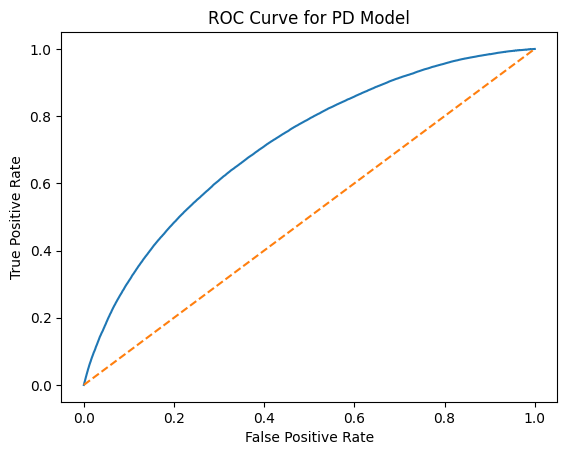

In [26]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_port, p_port)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve for PD Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

## 7.3 Calibration Check

Calibration measures whether predicted probabilities align with actual default rates. We group loans into deciles based on predicted PD and compare predicted risk to realized bad rates.

In [27]:
pd_eval = pd.DataFrame({
    "pred_pd": p_port,
    "actual": y_test_port
})

pd_eval["decile"] = pd.qcut(pd_eval["pred_pd"], 10, labels=False) + 1

calibration = (
    pd_eval
    .groupby("decile")
    .agg(
        avg_pred_pd=("pred_pd", "mean"),
        actual_bad_rate=("actual", "mean"),
        count=("actual", "size")
    )
)

print(calibration)

        avg_pred_pd  actual_bad_rate  count
decile                                     
1          0.023986         0.024108  45214
2          0.045847         0.044368  45213
3          0.066227         0.064760  45213
4          0.085384         0.081745  45214
5          0.104287         0.097273  45213
6          0.123878         0.120120  45213
7          0.145307         0.143164  45214
8          0.171628         0.172495  45213
9          0.211385         0.228341  45213
10         0.337483         0.337550  45214


## 7.4 Calibration Plot

To visually evaluate model calibration, we compare predicted probabilities of default with observed bad rates across risk deciles. 

A well-calibrated model should produce points that lie close to the diagnol line, indicating that predicted probabilities match realized default rates.

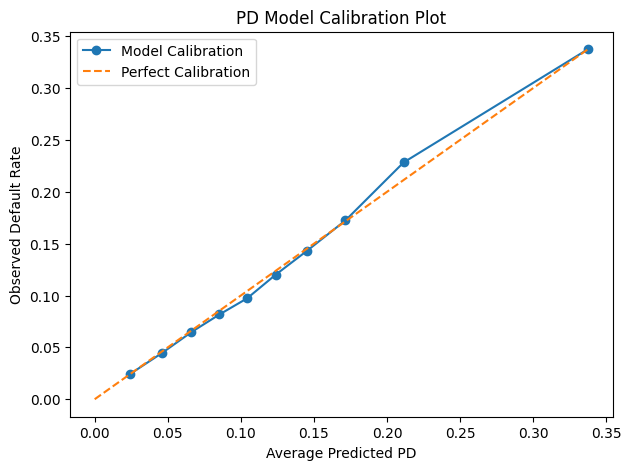

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    calibration["avg_pred_pd"],
    calibration["actual_bad_rate"],
    marker="o",
    label="Model Calibration"
)

plt.plot(
    [0, calibration["avg_pred_pd"].max()],
    [0, calibration["avg_pred_pd"].max()],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Average Predicted PD")
plt.ylabel("Observed Default Rate")

plt.title("PD Model Calibration Plot")

plt.legend()

plt.show()

## 7.5 Interpretation

The diagnostic analysis suggests that the Probability of Default (PD) model produces realistic and well-behaved risk estimates across the loan portfolio.

The distribution of predicted PD values shows that most loans fall within relatively low probability ranges, generally below 0.20, while a smaller portion of loans appear in higher risk ranges extending toward 0.60. This right-skewed distribution is typical in consumer credit portfolios, where the majority of borrowers are relatively low risk and a smaller tail of borrowers carries substantially higher default risk.

The ROC curve indicates that the model has meaningful discriminatory power in distinguishing between good and bad loans. The curve lies clearly above the random classification line, consistent with the previously observed ROC AUC of approximately **0.72**. This suggests the model can correctly rank higher-risk borrowers above lower-risk borrowers roughly 72% of the time, which represents a reasonable level of predictive performance for consumer lending data.

The calibration analysis further demonstrates that predicted probabilities align closely with realized default rates across deciles of predicted risk. For example, the lowest risk decile shows an average predicted PD of approximately **2.4%**, which closely matches the observed bad rate of **2.4%**, while the highest risk decile has a predicted PD of roughly **33.7%**, nearly identical to the observed default rate of **33.8%**. This close agreement across deciles indicates that the model’s probability estimates are well calibrated and can be interpreted as meaningful estimates of borrower default risk. The calibration plot further confirms that predicted default probabilities closely match observed default rates across deciles, indicating that the model produces reliable probability estimates.

Overall, the diagnostic results show that the PD model provides both reasonable risk ranking and accurate probability calibration, supporting its use within the broader Expected Loss framework for portfolio credit risk analysis.

# Section 8 - Model Interpretation

## 8.1 Extract Model Coefficients

Logistic regression produces coefficients that indicate how each feature affects the probability of default. 

Positive coefficients increase default risk, while negative coefficients decrease default risk. 

We extract the model coefficients to identify the variables most strongly associated with borrower risk. 

In [29]:
# Get feature names after preprocessing
feature_names = PD_port_CLF.named_steps["preprocessor"].get_feature_names_out()

# Get model coefficients
coefficients = PD_port_CLF.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient
20,cat__grade_G,2.140034
19,cat__grade_F,1.743918
18,cat__grade_E,0.935665
50,cat__sub_grade_F5,0.594527
49,cat__sub_grade_F4,0.550071
45,cat__sub_grade_E5,0.533737
52,cat__sub_grade_G2,0.476288
2,num__installment,0.450497
53,cat__sub_grade_G3,0.444596
54,cat__sub_grade_G4,0.423437


## 8.2 Highest Risk Drivers

Features with the largest positive coefficients are associated with increased probability of default. 

These variables represent borrower characteristics that signal higher credit risk.

In [30]:
coef_df.head(15)

,feature,coefficient
20,cat__grade_G,2.140034
19,cat__grade_F,1.743918
18,cat__grade_E,0.935665
50,cat__sub_grade_F5,0.594527
49,cat__sub_grade_F4,0.550071
45,cat__sub_grade_E5,0.533737
52,cat__sub_grade_G2,0.476288
2,num__installment,0.450497
53,cat__sub_grade_G3,0.444596
54,cat__sub_grade_G4,0.423437


## 8.3 Strongest Protective Factors

Features with negative coefficients decrease the probability of default and are associated with stronger borrowers.

In [31]:
coef_df.sort_values("coefficient").head(15)

,feature,coefficient
14,cat__grade_A,-2.916829
15,cat__grade_B,-1.659992
21,cat__sub_grade_A1,-1.368568
1,num__int_rate,-0.873309
26,cat__sub_grade_B1,-0.812224
22,cat__sub_grade_A2,-0.787983
16,cat__grade_C,-0.731682
27,cat__sub_grade_B2,-0.586286
31,cat__sub_grade_C1,-0.551199
23,cat__sub_grade_A3,-0.550504


## 8.4 Odds Ratios

To improve interpretability, we convert coefficients to odds ratios. 

An odds ratio greater than 1 increases default odds, while an odds ratio less than 1 decreases default odds. 

In [32]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df.sort_values("odds_ratio", ascending=False).head(10)

,feature,coefficient,odds_ratio
20,cat__grade_G,2.140034,8.499724
19,cat__grade_F,1.743918,5.719711
18,cat__grade_E,0.935665,2.548907
50,cat__sub_grade_F5,0.594527,1.812174
49,cat__sub_grade_F4,0.550071,1.733376
45,cat__sub_grade_E5,0.533737,1.705294
52,cat__sub_grade_G2,0.476288,1.610087
2,num__installment,0.450497,1.569092
53,cat__sub_grade_G3,0.444596,1.559860
54,cat__sub_grade_G4,0.423437,1.527202


## 8.5 Interpretation

The logistic regression model highlights several borrower characteristics that strongly influence default risk. 

Loan credit grades appear as the dominant risk drivers in the model. Lower credit grades are associated with substantially higher default risk. For example, loans with **Grade G** have an odds ratio of approximately **8.5**, indicating that these borrowers are over eight times more likely to default compared to baseline grade category. Similarly, **Grade F** loans show odds ratios above **5**, while **Grade E** loans exhibit odds ratios around **2.5**, demonstrating the strong relationship between credit grade and default probability.

Sub0grade variables provide additional granularity within each grade category. Several lower sub-grades such as **F5**, **F4**, **E2**, and **G2** show elevated odds ratios between 1.5 and 1.8, indicating progressively higher credit risk within weaker grade categories. 

Beyond credit grades, several borrower-level financial variables also contribute to default risk. For example, the **loan installment amount** appears as a positive risk driver, suggesting that borrowers with larger monthly payment obligations are more likely to experience repayment difficulty. 

Conversely, stronger borrower credit grades significantly reduce default risk. Loans with **Grade A** and **Grade B** exhibit large negative coefficients, indicating that these borrowers have substantially lower probability of default relative to weaker credit categories. 

Overall, the model identifies credit grade as the primary determinant of default risk, with borrower payment burden and sub-grade distinctions providing additional predictive power. This pattern is consistent with expectations because LendingClub credit grades summarize multiple underlying borrower characteristics such as credit history, debt burden, and repayment capacity.

These results confirm that the model captures economically intuitive drivers of credit risk, providing confidence that the PD model can be used within the broader Expected Loss framework.